data/raw/1154776/Se-U-Ra - Tsui no Maihime (DarkistDeci) [Hard].osu


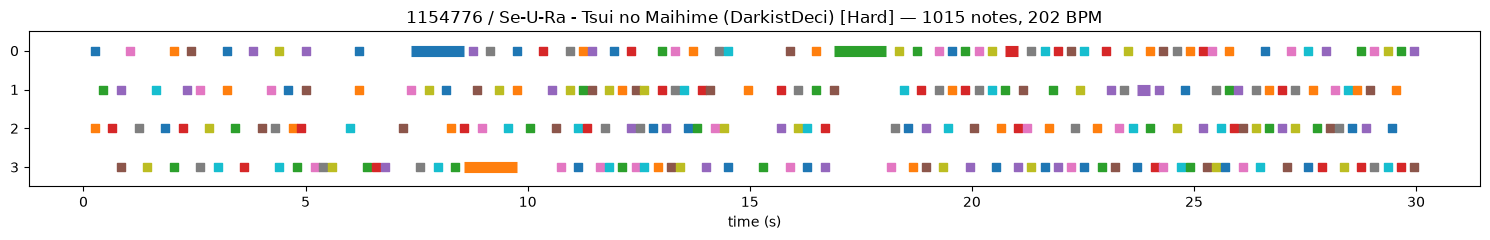

In [7]:
import random
import matplotlib.pyplot as plt
from pathlib import Path
from src.data.chart_parser import parse_osu

def plot_chart(chart, t0=0, t1=30_000, title=""):
    fig, ax = plt.subplots(figsize=(15, 2.5))
    for n in chart.notes:
        if not (t0 <= n.time_ms <= t1):
            continue
        if n.end_ms:
            ax.plot([n.time_ms/1000, n.end_ms/1000], [n.lane]*2, lw=8,
                    solid_capstyle="butt")
        else:
            ax.scatter(n.time_ms/1000, n.lane, s=40, marker="s")
    ax.set_yticks(range(chart.key_count))
    ax.set_ylim(-0.5, chart.key_count - 0.5)
    ax.invert_yaxis()                      # 게임 화면과 같은 방향
    ax.set_xlabel("time (s)"); ax.set_title(title)
    plt.tight_layout(); plt.show()

def pick_random_chart(root=Path("data/raw")):
    candidates = list(root.glob("*/*.osu"))
    if not candidates:
        raise FileNotFoundError(f"No .osu files found under {root}")

    random.shuffle(candidates)
    for path in candidates:
        try:
            return path, parse_osu(path)
        except ValueError:
            continue

    raise ValueError(f"No mania charts found under {root}")

p, c = pick_random_chart()
print(p)
plot_chart(c, title=f"{p.parent.name} / {p.stem} — {len(c.notes)} notes, {c.bpm:.0f} BPM")